# Step 2 Part B: Exploring volatility regimes and deciding train/val/test splits

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("btc_options_cleaned.csv")
df["hour_bucket"] = pd.to_datetime(df["hour_bucket"])
print(f"{len(df)} rows, {df['hour_bucket'].min()} to {df['hour_bucket'].max()}")
df.head()

490329 rows, 2019-12-31 18:00:00 to 2024-12-01 23:00:00


,symbol,hour_bucket,timestamp,type,strike_price,expiration,open_interest,bid_price,bid_amount,bid_iv,...,gamma,vega,theta,datetime,expiration_dt,time_to_maturity_days,moneyness,mid_price,bid_ask_spread,relative_spread
0,BTC-10JAN20-5750-C,2019-12-31 23:00:00,1577836798404000,call,5750.0,1578643200000000,0.5,0.1990,0.1,NaN,...,0.00008,0.78771,-3.22966,2019-12-31 23:59:58.404,2020-01-10 08:00:00,9.375000,0.800791,0.20525,0.0125,0.060901
1,BTC-10JAN20-5750-C,2020-01-01 00:00:00,1577840398404000,call,5750.0,1578643200000000,0.5,0.1975,0.1,48.98,...,0.00008,0.81033,-3.34768,2020-01-01 00:59:58.404,2020-01-10 08:00:00,9.333333,0.802346,0.20450,0.0140,0.068460
2,BTC-10JAN20-5750-C,2020-01-01 01:00:00,1577843998404000,call,5750.0,1578643200000000,0.5,0.2020,0.1,45.29,...,0.00007,0.75970,-3.17613,2020-01-01 01:59:58.404,2020-01-10 08:00:00,9.291667,0.797905,0.20675,0.0095,0.045949
3,BTC-10JAN20-5750-C,2020-01-01 02:00:00,1577847595134000,call,5750.0,1578643200000000,0.5,0.2045,0.1,51.50,...,0.00007,0.74962,-3.19228,2020-01-01 02:59:55.134,2020-01-10 08:00:00,9.250000,0.795106,0.20800,0.0070,0.033654
4,BTC-10JAN20-5750-C,2020-01-01 03:00:00,1577851198405000,call,5750.0,1578643200000000,0.5,0.2025,0.1,36.12,...,0.00008,0.77874,-3.34269,2020-01-01 03:59:58.405,2020-01-10 08:00:00,9.208333,0.797161,0.20700,0.0090,0.043478


## Why not realized volatility from price?
Our dataset only has ONE real day of data per month (the free Tardis sample). A rolling realized-volatility calculation built on that requires interpolating ~29 missing days between each sampled day. Linear interpolation has zero realized volatility by construction, so a rolling window built on it is measuring mostly artificial flatness, not real market behavior -- that's why the first attempt at this plot looked like a jagged sawtooth with implausibly low values.

## Better approach: implied volatility per sampled day
Instead, use `mark_iv` -- Deribit's own implied volatility for each option -- computed only on the real, observed sampled days (no interpolation needed). We'll take the median ATM (moneyness close to 1.0) implied vol on each sampled day as our regime indicator. This is also more directly relevant to an options-hedging study than realized volatility would be.

In [2]:
import numpy as np

# Near-the-money options only, for a clean regime signal
atm = df[(df["moneyness"] >= 0.95) & (df["moneyness"] <= 1.05)].copy()
atm["sample_date"] = atm["hour_bucket"].dt.date

# Median ATM implied vol per sampled day (mark_iv is usually already in % -- check the scale)
daily_iv = atm.groupby("sample_date")["mark_iv"].median().sort_index()
daily_iv.index = pd.to_datetime(daily_iv.index)
print(daily_iv.describe())
daily_iv.head()

count     84.000000
mean      62.782500
std       18.029025
min       32.420000
25%       50.170000
50%       57.210000
75%       73.727500
max      110.900000
Name: mark_iv, dtype: float64


sample_date
2019-12-31    51.215
2020-01-01    53.150
2020-01-31    52.895
2020-02-01    52.750
2020-02-29    53.690
Name: mark_iv, dtype: float64

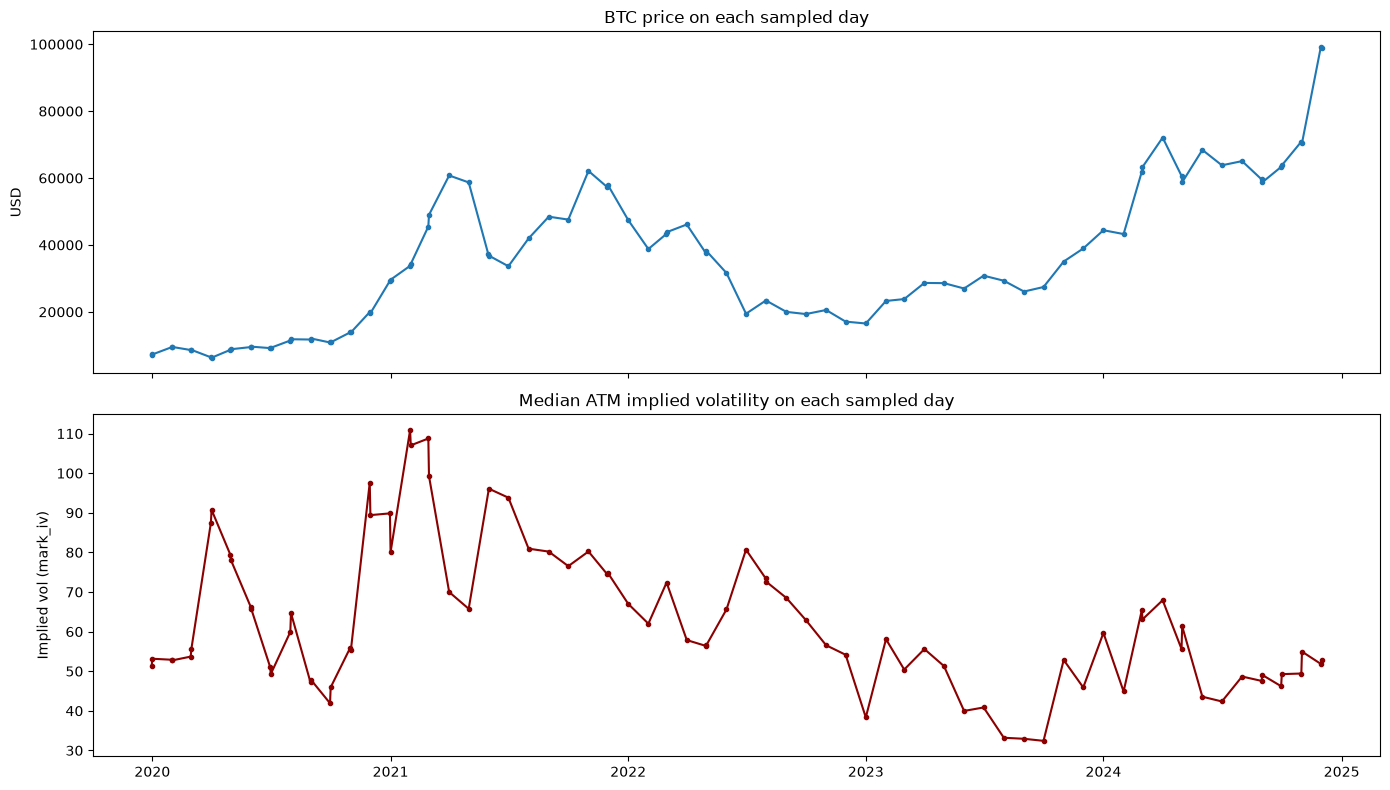

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily BTC price on each sampled day (median underlying price that day)
daily_price = df.groupby(df["hour_bucket"].dt.date)["underlying_price"].median()
daily_price.index = pd.to_datetime(daily_price.index)
axes[0].plot(daily_price.index, daily_price.values, marker="o", markersize=3)
axes[0].set_title("BTC price on each sampled day")
axes[0].set_ylabel("USD")

axes[1].plot(daily_iv.index, daily_iv.values, marker="o", markersize=3, color="darkred")
axes[1].set_title("Median ATM implied volatility on each sampled day")
axes[1].set_ylabel("Implied vol (mark_iv)")

plt.tight_layout()
plt.show()

## Decide split boundaries
Look at the plot above. We want train/val/test to each contain a mix of calm and volatile periods, in **chronological** order (train earliest, test latest -- no shuffling). A reasonable starting point: ~70% train / 15% val / 15% test by date, then adjust based on what the vol plot shows.

In [4]:
# Adjust these dates after looking at the plot above
TRAIN_END = "2023-01-01"
VAL_END = "2023-09-01"
# test = everything after VAL_END

train = df[df["hour_bucket"] < TRAIN_END]
val = df[(df["hour_bucket"] >= TRAIN_END) & (df["hour_bucket"] < VAL_END)]
test = df[df["hour_bucket"] >= VAL_END]

print(f"Train: {len(train)} rows, {train['hour_bucket'].min()} to {train['hour_bucket'].max()}")
print(f"Val:   {len(val)} rows, {val['hour_bucket'].min()} to {val['hour_bucket'].max()}")
print(f"Test:  {len(test)} rows, {test['hour_bucket'].min()} to {test['hour_bucket'].max()}")

Train: 187961 rows, 2019-12-31 18:00:00 to 2022-12-01 23:00:00
Val:   64474 rows, 2023-01-01 00:00:00 to 2023-08-01 23:00:00
Test:  237894 rows, 2023-09-01 00:00:00 to 2024-12-01 23:00:00


In [5]:
train.to_csv("btc_options_train.csv", index=False)
val.to_csv("btc_options_val.csv", index=False)
test.to_csv("btc_options_test.csv", index=False)
print("Saved train/val/test splits.")

Saved train/val/test splits.
